# 00 · Richness backbone — the objective, the rubric, and where V0–V5 sit

**Goal (user):** *richer signals — more **informative** deviations (threshold crossings / turning
points / extremes) per unit time — without degenerating into noise.*

This notebook builds the **measurement backbone**. It scores the existing versions V0–V5 on a
richness rubric and a **strict out-of-sample gate**, establishing the current frontier that the new
signals (V6 roofing, V7 breadth, V8 change-point, V9 blend) must beat.

**The rubric** (`positioning.versions.richness`), synthesised from the research:
- *Richness*: crossings/yr at 0/±1/±2σ, turning-points/yr vs the **Bienaymé** random benchmark
  (`E[p]=⅔(n−2)`), **Rice's-formula** crossing budget.
- *Structure*: OU half-life, spectral entropy, effective sample size `n_eff`.
- *Information*: Spearman **IC** vs forward Δ10Y + Newey–West t; mutual information.
- *Strict gate*: the **incremental** deviations (ones a candidate has that V0 lacks) must carry IC
  that (a) is >0, (b) beats an **AR(1)/IAAFT surrogate** (p<0.05), (c) survives **CPCV purge+embargo**,
  (d) clears **t>3** / Deflated-Sharpe. Richness that fails this is labelled *manufactured noise*.

*Refs: Rice 1944; Bienaymé/Kendall turning-point test; López de Prado (Deflated Sharpe, PBO, CPCV);
Grinold–Kahn (IR=IC·√breadth).*

In [1]:
import sys, os
# Make the notebook self-sufficient: walk up from cwd to the repo root (dir containing `positioning`).
_root = os.getcwd()
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, "positioning")):
    _root = os.path.dirname(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)

import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    def display(x): print(x)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
ORANGE="#FF8200"; GREY="#3C3C3C"; BLUE="#1F4E79"; RED="#C00000"; GREEN="#2E7D32"; PURPLE="#7030A0"; TEAL="#0F9D9D"

from positioning.versions import base, compare, richness, dsp, transforms
from positioning.versions import params as P
from positioning.versions.base import responsiveness

def show(df, n=None):
    """Render a DataFrame/dict, truncated."""
    try:
        display(df if n is None else df.head(n))
    except Exception:
        print(df)

def zline(ax, bounded=False):
    """Draw crowd bands for a composite axis."""
    if bounded:
        ax.axhline(80, color=RED, ls="--", lw=0.7); ax.axhline(20, color=GREEN, ls="--", lw=0.7)
    else:
        for k in (1.5, -1.5): ax.axhline(k, color=GREY, ls="--", lw=0.6)
        ax.axhline(0, color=GREY, lw=0.4)

def crossings(z, level=0.0):
    """Count sign changes of (z-level): a proxy for 'deviations per unit time'."""
    s = z.dropna().astype(float) - level
    return int((np.sign(s).diff().abs() > 0).sum())

print("loaded versions package — building shared inputs (cache-first)…")
inp = base.load_inputs()
y10 = inp.y10_w
print(f"inputs: {len(inp.report_dates)} weekly dates {inp.report_dates.min().date()}..{inp.report_dates.max().date()}")

loaded versions package — building shared inputs (cache-first)…


inputs: 422 weekly dates 2018-06-19..2026-07-14


## Build every version on the same inputs

In [2]:
inp, results = compare.build_all()
keys = ["v0","v1","v2","v3","v4","v5"]
for k in keys:
    r = results[k]; c = r.composite.dropna()
    print(f"{k:3s}  n={len(c):3d}  latest={(c.iloc[-1] if len(c) else float('nan')):+8.3f}  {r.name}")

/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


v0   n=268  latest=  +0.272  V0 Production (2x 3y-z + PCA)
v1   n=422  latest=  -9.081  V1 Kaiser-PCA (single-std, eigenvalue>1)
v2   n=397  latest= +85.541  V2 CFTC/Street best-practice (COT-index + %OI + flow)
v3   n=384  latest=  +0.605  V3 EWMA/52w single-pass
v4   n=397  latest=  +1.421  V4 Curve (book-tilt vs momentum, PC2)
v5   n=243  latest=  -0.403  V5 Kalman (deviation-σ / slope / acceleration)


## The richness scorecard (V0 = baseline for the incremental-IC gate)

In [3]:
sc = richness.scorecard({k: results[k] for k in keys}, inp.y10_w, baseline_key="v0")
show(sc.round(3))

,cross0_per_yr,cross1_per_yr,cross2_per_yr,turns_per_yr,bienayme_z,half_life_wk,spectral_entropy,ic_8w,ic_t_8w,incr_ic,surrogate_p,cpcv_ic,gate_pass
v0,6.209,7.567,4.269,33.955,-0.339,4.567,0.520,0.163,0.692,NaN,NaN,NaN,False
v1,1.355,1.602,0.493,26.123,-7.868,414.106,0.195,0.139,NaN,-0.291,0.222,0.114,False
v2,2.620,7.859,0.000,23.970,-9.584,18.080,0.371,-0.027,-0.065,-0.374,0.160,-0.163,False
v3,5.281,5.281,1.490,25.729,-7.845,10.651,0.525,-0.093,-0.286,-0.645,0.057,-0.227,False
v4,4.715,11.919,1.310,27.244,-6.602,8.330,0.590,0.026,0.101,-0.061,0.853,-0.005,False
v5,23.325,23.539,7.276,36.593,1.578,0.663,0.879,-0.038,-0.585,-0.374,0.010,-0.021,False


### Reading the scorecard
- **crossings/yr, turns/yr** ↑ = richer (more deviations). Compare against **V0** (very smooth/slow).
- **bienayme_z** near/above ~0 means turns are no more than random — richness alone is cheap.
- **incr_ic / surrogate_p / cpcv_ic / gate_pass** = the honesty columns. A version can be far richer
  than V0 yet **fail** the gate — that is the signal we care about.

## Composites through time — visualising 'deviations per unit time'

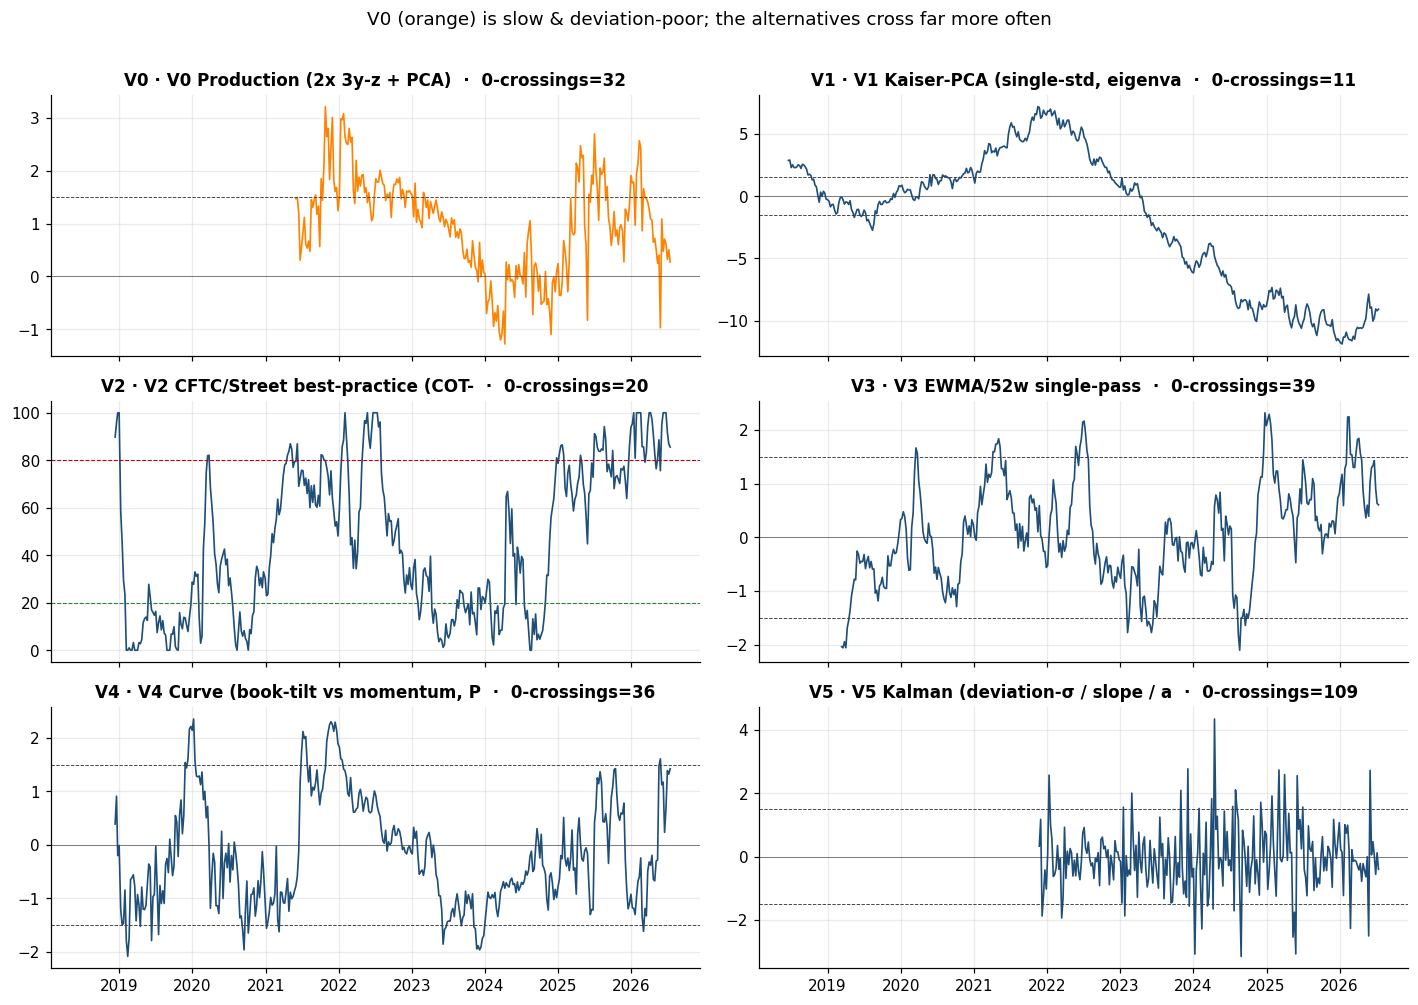

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)
for ax, k in zip(axes.ravel(), keys):
    r = results[k]; c = r.composite.dropna()
    col = ORANGE if k=="v0" else BLUE
    ax.plot(c.index, c.values, color=col, lw=1.1)
    zline(ax, r.bounded)
    nx = crossings(richness.to_z(c, r.bounded))
    ax.set_title(f"{k.upper()} · {r.name[:34]}  ·  0-crossings={nx}")
fig.suptitle("V0 (orange) is slow & deviation-poor; the alternatives cross far more often", y=1.01)
fig.tight_layout(); display(fig); plt.close(fig)

## Efficient frontier — turns/yr vs forward informativeness

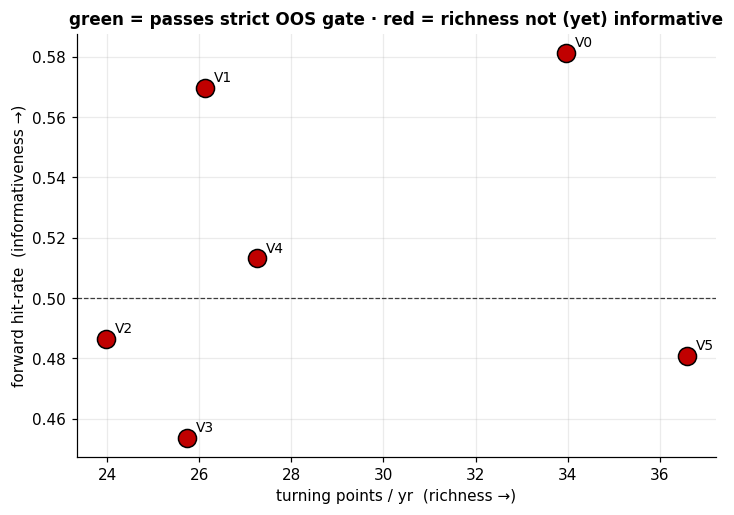

,version,turns_per_yr,hit_rate,gate_pass
0,v0,33.955,0.581,False
1,v1,26.123,0.570,False
2,v2,23.970,0.486,False
3,v3,25.729,0.454,False
4,v4,27.244,0.513,False
5,v5,36.593,0.481,False


In [5]:
try:
    fr = richness.frontier(sc)
    fig, ax = plt.subplots(figsize=(7.5, 5))
    for _, row in fr.iterrows():
        passed = bool(row.get("gate_pass", False))
        ax.scatter(row["turns_per_yr"], row["hit_rate"],
                   s=140, color=(GREEN if passed else RED), edgecolor="k", zorder=3)
        ax.annotate(str(row["version"]).upper(), (row["turns_per_yr"], row["hit_rate"]),
                    xytext=(6,4), textcoords="offset points", fontsize=9)
    ax.axhline(0.5, color=GREY, ls="--", lw=0.8)
    ax.set_xlabel("turning points / yr  (richness →)"); ax.set_ylabel("forward hit-rate  (informativeness →)")
    ax.set_title("green = passes strict OOS gate · red = richness not (yet) informative")
    display(fig); plt.close(fig)
    show(fr.round(3))
except Exception as e:
    print("frontier:", type(e).__name__, e)

## Takeaway
The alternatives are all **richer** than V0 (more crossings/turns per year) — that was already known
from the methodology audit. The open question this project answers: **can we add deviations that are
also *informative* out-of-sample?** The next notebooks build V6/V7/V8, score each addition against
this exact rubric, and assemble only the survivors into V9.